# Analyse interactive de mes séances de course à pied

## 1 - Import des bibliothèques et fonctions auxiliares (tools.py)

On commence par importer les bibliothèques nécessaires pour le traitement des données, la visualisation, l'interaction et la création de tableaux interactifs.

In [1]:
import os
import pandas as pd

# Bibliothèques de visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import altair as alt

# Bibliothèque pour tableaux interactifs
from great_tables import *

# UI widgets
import ipywidgets as widgets
from IPython.display import display

# Fonctions utilitaires
from tools import prepare_dataframe, clean_end_dataframe, compute_indicators, classify_session

## 2 - Chargement des fichiers et préparation des données

On lit tous les fichiers `.fit`, on nettoie les données, on calcule les indicateurs de séance et on crée deux DataFrames principaux :

- `df_all` → toutes les séances concaténées

- `df_indicators` → tableau résumé par séance

In [2]:
data_folder = "data_fit"
fit_files = [f for f in os.listdir(data_folder) if f.endswith(".fit")]

all_sessions = []
all_indicators = []

for file in fit_files:
    # Préparation et nettoyage
    df_uncleaned = prepare_dataframe(os.path.join(data_folder, file))
    df_cleaned, last_running_index = clean_end_dataframe(df_uncleaned)
    
    # Ajout d'informations de session
    df_cleaned["session"] = file
    df_cleaned["last_running_index"] = last_running_index
    df_cleaned["type"] = classify_session(file)
    all_sessions.append(df_cleaned)
    
    # Calcul des indicateurs globaux
    indicators = compute_indicators(df_cleaned)
    indicators["session"] = file
    indicators["type"] = df_cleaned["type"].iloc[0]
    all_indicators.append(indicators)

# DataFrames finaux
df_all = pd.concat(all_sessions, ignore_index=True)
df_indicators = pd.DataFrame(all_indicators)

In [3]:
df_all.head()

,timestamp,distance,enhanced_speed,enhanced_altitude,heart_rate,cadence,elapsed_s,distance_km,pace_min_km,pace_smooth,session,last_running_index,type
0,2025-01-03 16:37:13,2.66,1.521,3.6,124,63,0.0,0.00266,10.957725,NaN,footing_Marseille2025-01-03.fit,652,Footing
1,2025-01-03 16:37:19,17.45,2.006,3.4,121,64,6.0,0.01745,8.308425,NaN,footing_Marseille2025-01-03.fit,652,Footing
2,2025-01-03 16:37:21,23.46,2.249,3.4,121,86,8.0,0.02346,7.410716,7.625912,footing_Marseille2025-01-03.fit,652,Footing
3,2025-01-03 16:37:27,43.55,2.874,3.4,119,86,14.0,0.04355,5.799130,6.557838,footing_Marseille2025-01-03.fit,652,Footing
4,2025-01-03 16:37:34,64.49,2.948,3.4,121,86,21.0,0.06449,5.653562,6.002105,footing_Marseille2025-01-03.fit,652,Footing


`df_all` contient toutes les données temporelles (allure, FC, altitude…).

In [4]:
df_indicators.head()

,Distance totale (km),Durée totale (min),Allure moyenne (min/km),FC moyenne (bpm),FC max (bpm),D+ (m),D- (m),session,type
0,8.39399,53.450000,6.483739,149.096478,158,72.6,79.8,footing_Marseille2025-01-03.fit,Footing
1,9.47131,57.566667,6.017032,151.242254,160,95.2,75.4,footing_Marseille2025-01-08.fit,Footing
2,10.75026,62.566667,5.835841,147.683686,161,48.0,115.4,footing_Marseille2025-01-28.fit,Footing
3,10.15659,61.416667,6.266462,145.471166,157,65.8,97.0,footing_Marseille2025-02-12.fit,Footing
4,8.02212,45.716667,5.735215,157.781487,177,93.8,115.2,footing_Venelles2024-12-28.fit,Footing


`df_indicators` résume la performance globale de chaque séance.

## 3 - Sélection des séances via widgets

On crée des widgets interactifs pour choisir le type de séance et les séances à analyser. Cela rend toutes les visualisations suivantes interactives.

In [5]:
# Choix du type de séance
type_dropdown = widgets.Dropdown(
    options=df_all["type"].unique().tolist(),
    value=df_all["type"].unique()[0],
    description="Type :",
)

# Choix des séances
sessions_dropdown = widgets.SelectMultiple(
    options=[],
    description="Séances :",
)

# Mise à jour dynamique de la liste des séances en fonction du type
def update_sessions(*args):
    selected_type = type_dropdown.value
    sessions = df_all[df_all["type"] == selected_type]["session"].unique().tolist()
    sessions_dropdown.options = sessions
    sessions_dropdown.value = tuple(sessions[:min(2,len(sessions))])

type_dropdown.observe(update_sessions, names="value")
update_sessions()
display(type_dropdown, sessions_dropdown)

Dropdown(description='Type :', options=('Footing', 'Fractionné', 'Compétition', 'Sortie longue', 'Tempo'), val…

SelectMultiple(description='Séances :', index=(0, 1), options=('footing_Marseille2025-01-03.fit', 'footing_Mar…

## 4 - Visualisations des données avec des graphiques

### a. Analyse temporelle : Matplotlib
Ces graphiques permettent d’analyser l’évolution de l’allure, la fréquence cardiaque et l’altitude dans le temps.  
On trace plusieurs combinaisons pour mieux comprendre les liens entre les paramètres physiologiques et le terrain.

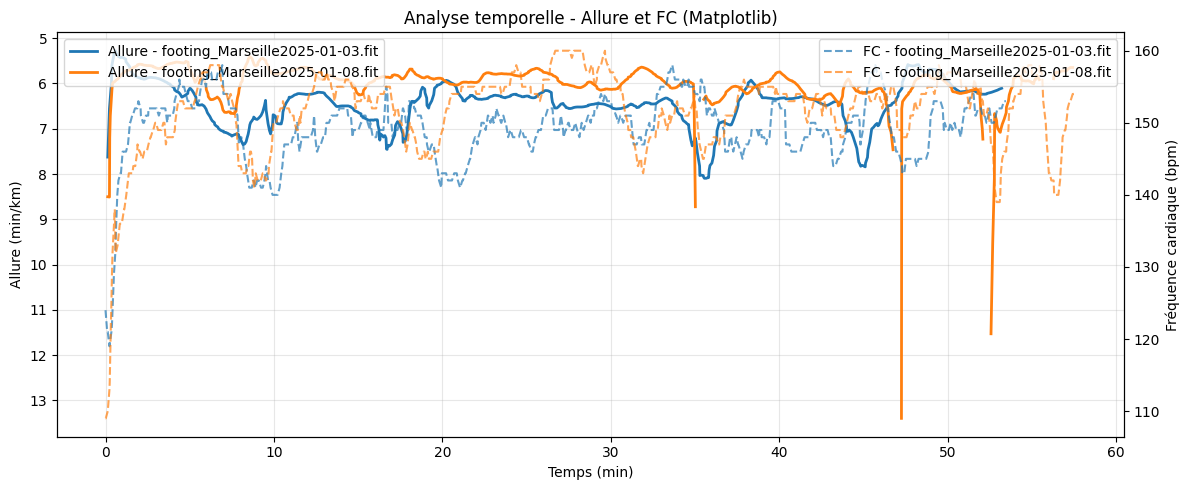

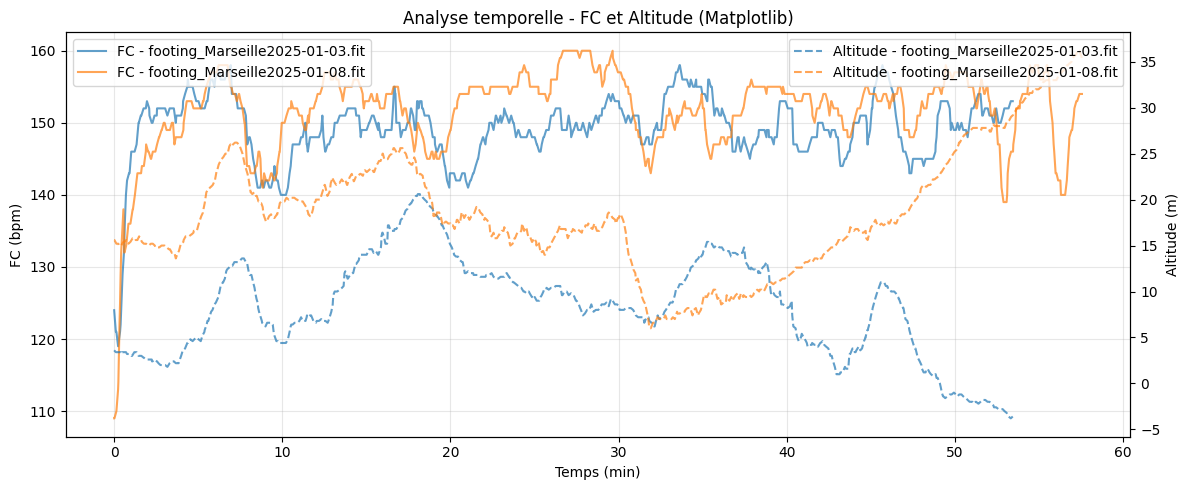

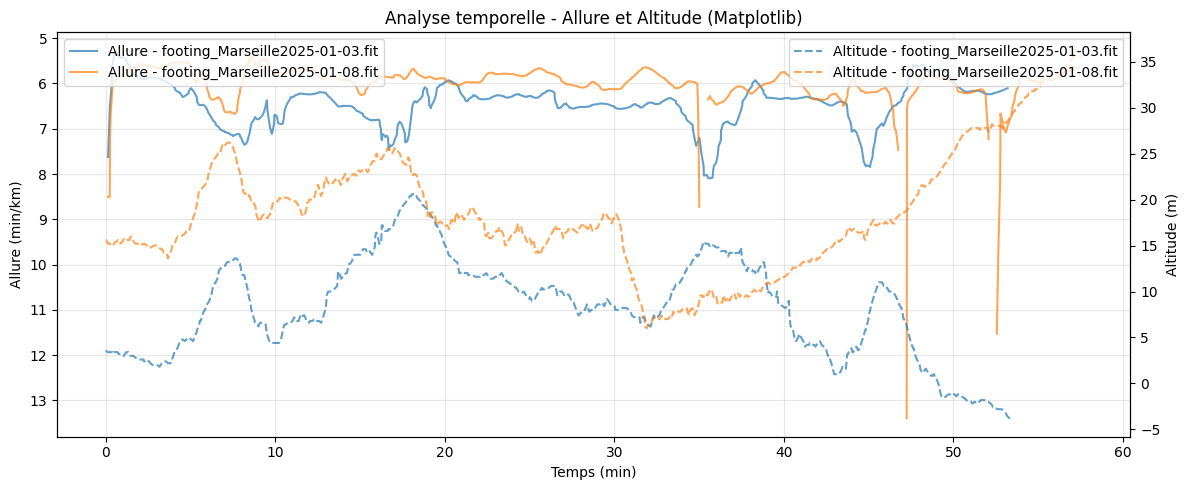

In [6]:
def plot_matplotlib(selected_sessions):
    # Allure + FC
    fig, ax1 = plt.subplots(figsize=(12,5))
    for session in selected_sessions:
        df_s = df_all[df_all["session"]==session]
        ax1.plot(df_s["elapsed_s"]/60, df_s["pace_smooth"], label=f"Allure - {session}", linewidth=2)
    ax1.set_xlabel("Temps (min)")
    ax1.set_ylabel("Allure (min/km)")
    ax1.invert_yaxis()  # allure descendante = plus rapide
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    for session in selected_sessions:
        df_s = df_all[df_all["session"]==session]
        ax2.plot(df_s["elapsed_s"]/60, df_s["heart_rate"], '--', label=f"FC - {session}", alpha=0.7)
    ax2.set_ylabel("Fréquence cardiaque (bpm)")

    plt.title("Analyse temporelle - Allure et FC (Matplotlib)")
    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

    # FC + Altitude
    fig, ax1 = plt.subplots(figsize=(12,5))
    for session in selected_sessions:
        df_s = df_all[df_all["session"]==session]
        ax1.plot(df_s["elapsed_s"]/60, df_s["heart_rate"], label=f"FC - {session}", alpha=0.7)
    ax1.set_xlabel("Temps (min)")
    ax1.set_ylabel("FC (bpm)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    for session in selected_sessions:
        df_s = df_all[df_all["session"]==session]
        ax2.plot(df_s["elapsed_s"]/60, df_s["enhanced_altitude"], '--', label=f"Altitude - {session}", alpha=0.7)
    ax2.set_ylabel("Altitude (m)")

    plt.title("Analyse temporelle - FC et Altitude (Matplotlib)")
    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

    # Allure + Altitude
    fig, ax1 = plt.subplots(figsize=(12,5))
    for session in selected_sessions:
        df_s = df_all[df_all["session"]==session]
        ax1.plot(df_s["elapsed_s"]/60, df_s["pace_smooth"], label=f"Allure - {session}", alpha=0.7)
    ax1.set_xlabel("Temps (min)")
    ax1.set_ylabel("Allure (min/km)")
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    for session in selected_sessions:
        df_s = df_all[df_all["session"]==session]
        ax2.plot(df_s["elapsed_s"]/60, df_s["enhanced_altitude"], '--', label=f"Altitude - {session}", alpha=0.7)
    ax2.set_ylabel("Altitude (m)")

    plt.title("Analyse temporelle - Allure et Altitude (Matplotlib)")
    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

plot_matplotlib(sessions_dropdown.value)

**Interprétation**
- L’inversion de l’axe des allures permet de visualiser les moments où on accélère clairement.
- Comparer allure et FC permet de détecter la fatigue ou les moments intenses.
- Comparer allure et altitude montre l’impact du terrain sur la performance.

### b. Analyse statistique : Seaborn

Ces graphiques permettent d’analyser la régularité et la charge interne de la séance.  
On trace la distribution des allures et la variabilité de la fréquence cardique.

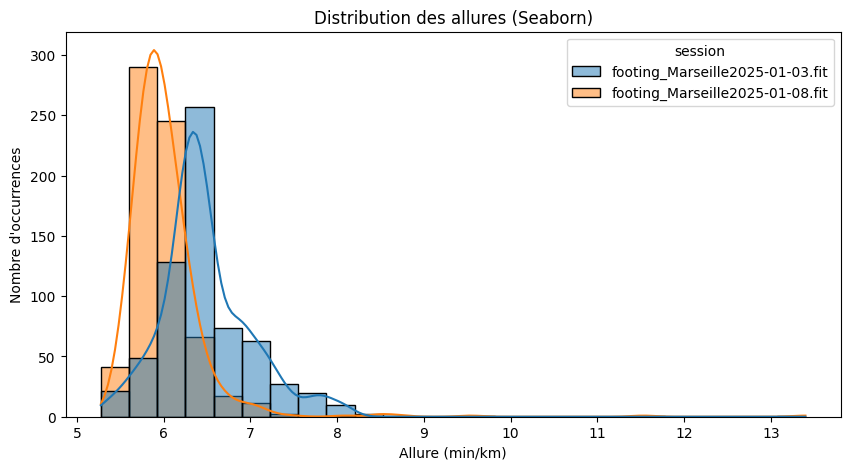

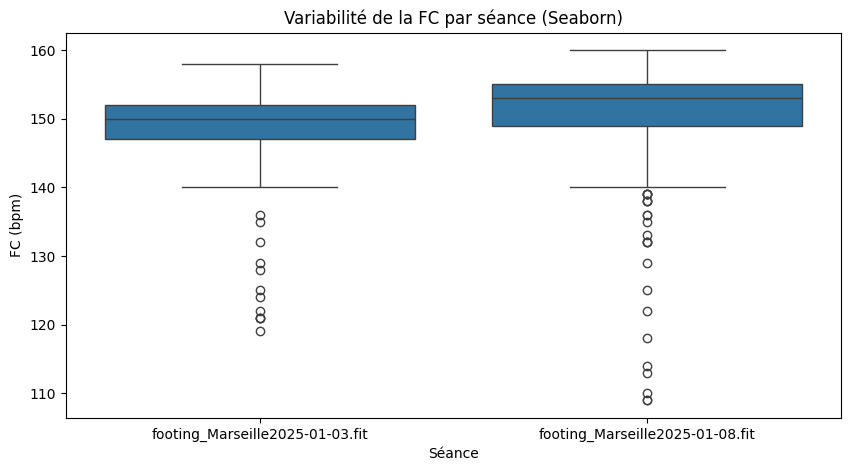

In [7]:
def plot_seaborn(selected_sessions):
    df_subset = df_all[df_all["session"].isin(selected_sessions)].copy()
    
    # Distribution de l'allure moyenne par séance
    plt.figure(figsize=(10,5))
    sns.histplot(data=df_subset, x="pace_smooth", hue="session", kde=True, bins=25)
    plt.xlabel("Allure (min/km)")
    plt.ylabel("Nombre d'occurrences")
    plt.title("Distribution des allures (Seaborn)")
    plt.show()
    
    # Distribution de la FC moyenne par séance (boxplot)
    plt.figure(figsize=(10,5))
    sns.boxplot(x="session", y="heart_rate", data=df_subset)
    plt.xlabel("Séance")
    plt.ylabel("FC (bpm)")
    plt.title("Variabilité de la FC par séance (Seaborn)")
    plt.show()

plot_seaborn(sessions_dropdown.value)

**Interprétation**
- Histogramme → montre si la séance a été régulière ou si des phases lentes/rapides sont présentes.
- Boxplot FC → détection des pics de FC et de la charge physiologique.

### c. Analyse interactive des segments : Ploty

On peut filtrer les segments Montée/Plat/Descente et visualiser l’allure dans le temps pour chaque type de segment.

In [8]:
import plotly.express as px

# Calculer les segments montée/descente/plat
def compute_segments(group):
    group = group.copy()
    group['diff_elev'] = group['enhanced_altitude'].diff().fillna(0)
    group['montée_descente'] = 'Plat'
    group.loc[group['diff_elev'] > 0, 'montée_descente'] = 'Montée'
    group.loc[group['diff_elev'] < 0, 'montée_descente'] = 'Descente'
    return group

df_all = df_all.groupby('session', group_keys=False).apply(compute_segments)

# Visualisation interactive avec sélection des segments
def plot_segments_selectable(selected_sessions):
    # Widget multi-select pour les segments
    segment_options = ["Montée", "Plat", "Descente"]
    segment_selector = widgets.SelectMultiple(
        options=segment_options,
        value=segment_options,
        description='Segments :'
    )

    def update_plot(selected_segments):
        for session in selected_sessions:
            df_s = df_all[df_all["session"] == session].copy()
            df_s = df_s[df_s["montée_descente"].isin(selected_segments)]

            fig = px.scatter(
                df_s,
                x="elapsed_s",
                y="pace_smooth",
                color="montée_descente",
                color_discrete_map={"Montée":"red", "Plat":"green", "Descente":"blue"},
                opacity=0.5,  # points semi-transparents
                hover_data=["heart_rate","enhanced_altitude"]
            )

            fig.update_layout(
                title=f"Allure vs Temps - {session}",
                xaxis_title="Temps (s)",
                yaxis_title="Allure (min/km)",
                height=450,
                width=900,
                legend_title="Segment"
            )

            fig.show()

    out = widgets.interactive_output(
        update_plot,
        {'selected_segments': segment_selector}
    )

    display(segment_selector, out)

# Exemple d'utilisation
plot_segments_selectable(sessions_dropdown.value)

C:\Users\marga\AppData\Local\Temp\ipykernel_27440\3230746165.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all = df_all.groupby('session', group_keys=False).apply(compute_segments)


SelectMultiple(description='Segments :', index=(0, 1, 2), options=('Montée', 'Plat', 'Descente'), value=('Mont…

Output()

**Interprétation**
- Montée → l’allure diminue généralement.
- Plat → rythme plus stable.
- Descente → allure augmente souvent.

### d. Analyse relationnelle : Altair

Scatter plot interactif pour explorer la relation entre FC et allure, avec la couleur selon la séance et un tooltip pour altitude et temps.

In [9]:
def plot_altair(selected_sessions):
    df_sess = df_all[df_all["session"].isin(selected_sessions)].copy()
    chart = alt.Chart(df_sess).mark_circle(size=60, opacity=0.6).encode(
        x="pace_smooth",
        y="heart_rate",
        color="session",
        tooltip=["session","elapsed_s","pace_smooth","heart_rate","enhanced_altitude"]
    ).interactive().properties(
        width=800,
        height=500,
        title="Relation Allure vs FC (Altair)"
    )
    display(chart)

plot_altair(sessions_dropdown.value)


alt.Chart(...)

**Interprétation**
- Permet de détecter les zones où la FC est disproportionnée par rapport à l’allure.
- Utile pour repérer fatigue ou phases d’intensité.

## 5 - Tableau interactif : GreatTables

Résumé des indicateurs par séance, avec couleurs adaptatives et mini-barres.

In [10]:
df_table = df_indicators.copy()

# Réordonner les colonnes
cols_order = ["session","type","Distance totale (km)","Durée totale (min)","Allure moyenne (min/km)",
              "FC moyenne (bpm)","FC max (bpm)","D+ (m)","D- (m)"]
df_table = df_table[cols_order]

# Arrondi à 2 décimales
for col in cols_order[2:]:
    df_table[col] = df_table[col].round(2)

# Fonction pour colorer avec texte adaptatif
def color_cell_adaptive(val, vmin, vmax, cmap_name="YlOrRd"):
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    color = cmap(norm(val))
    hex_color = matplotlib.colors.to_hex(color)
    r, g, b, _ = color
    luminance = 0.299*r + 0.587*g + 0.114*b
    text_color = "black" if luminance > 0.5 else "white"
    return f"<div style='background-color:{hex_color};color:{text_color};padding:3px'>{val}</div>"

# Création du tableau
gt = GT(df_table)\
    .tab_spanner(label="Séance", columns=["session","type"])\
    .tab_spanner(label="Indicateurs", columns=df_table.columns[2:].tolist())\
    .cols_label(session="Séance", type="Type")\
    .cols_width(cases={"session":"20%", "type":"15%"})\
    .tab_style(style=[style.text(size="small")], locations=loc.body(df_table.columns.tolist()))\
    .tab_style(style=[style.text(weight="bold")], locations=loc.header())

# Palette différente par indicateur
gt = gt.fmt(fns=lambda val: color_cell_adaptive(val, df_table["Distance totale (km)"].min(), df_table["Distance totale (km)"].max(), "Blues"),
            columns=["Distance totale (km)"])
gt = gt.fmt(fns=lambda val: color_cell_adaptive(val, df_table["Durée totale (min)"].min(), df_table["Durée totale (min)"].max(), "Oranges"),
            columns=["Durée totale (min)"])
gt = gt.fmt(fns=lambda val: color_cell_adaptive(val, df_table["Allure moyenne (min/km)"].min(), df_table["Allure moyenne (min/km)"].max(), "Greens_r"),
            columns=["Allure moyenne (min/km)"])
gt = gt.fmt(fns=lambda val: color_cell_adaptive(val, df_table["FC moyenne (bpm)"].min(), df_table["FC moyenne (bpm)"].max(), "Purples"),
            columns=["FC moyenne (bpm)"])
gt = gt.fmt(fns=lambda val: color_cell_adaptive(val, df_table["FC max (bpm)"].min(), df_table["FC max (bpm)"].max(), "Purples"),
            columns=["FC max (bpm)"])

# Mini-barres pour D+ et D-
for col in ["D+ (m)", "D- (m)"]:
    gt = gt.fmt_nanoplot(columns=col) 

gt

GT(_tbl_data=                                  session           type  \
0         footing_Marseille2025-01-03.fit        Footing   
1         footing_Marseille2025-01-08.fit        Footing   
2         footing_Marseille2025-01-28.fit        Footing   
3         footing_Marseille2025-02-12.fit        Footing   
4          footing_Venelles2024-12-28.fit        Footing   
5      fractionne_Marseille2025-01-02.fit     Fractionné   
6      fractionne_Marseille2025-01-22.fit     Fractionné   
7      fractionne_Marseille2025-02-05.fit     Fractionné   
8          fractionne_Paris2025-03-25.fit     Fractionné   
9            race_Marathon-Paris-2025.fit    Compétition   
10         race_Marseille-Cassis-2025.fit    Compétition   
11  sortie-longue_Marseille2024-12-29.fit  Sortie longue   
12  sortie-longue_Marseille2025-01-05.fit  Sortie longue   
13  sortie-longue_Marseille2025-02-08.fit  Sortie longue   
14      sortie-longue_Paris2025-03-23.fit  Sortie longue   
15      sortie-longue_Paris2025-03-29.fit  Sortie longue   
16   sortie-longue_Venelles2025-01-25.fit  Sortie longue   
17   sortie-longue_Venelles2025-02-01.fit  Sortie longue   
18          tempo_Marseille2025-02-03.fit          Tempo   
19          tempo_Marseille2025-02-10.fit          Tempo   
20              tempo_Paris2025-03-11.fit          Tempo   
21              tempo_Paris2025-03-18.fit          Tempo   

    Distance totale (km)  Durée totale (min)  Allure moyenne (min/km)  \
0                   8.39               53.45                     6.48   
1                   9.47               57.57                     6.02   
2                  10.75               62.57                     5.84   
3                  10.16               61.42                     6.27   
4                   8.02               45.72                     5.74   
5                   4.78               25.00                     6.47   
6                   5.75               30.45                     6.46   
7                   8.79               44.27                     5.04   
8                  11.16               59.05                     5.40   
9                  42.60              267.82                     6.35   
10                 19.45              108.05                     5.53   
11                 13.02               75.15                     5.86   
12                 15.02               86.03                     5.98   
13                 21.78              131.30                     6.08   
14                 27.23              165.68                     6.21   
15                 20.71              122.07                     5.95   
16                 18.50              112.12                     6.10   
17                 19.71              122.87                     6.27   
18                  7.58               40.08                     5.37   
19                 11.26               60.08                     5.44   
20                  8.28               44.45                     5.86   
21                  8.25               45.03                     6.06   

    FC moyenne (bpm)  FC max (bpm)  D+ (m)  D- (m)  
0             149.10           158    72.6    79.8  
1             151.24           160    95.2    75.4  
2             147.68           161    48.0   115.4  
3             145.47           157    65.8    97.0  
4             157.78           177    93.8   115.2  
5             164.53           185     8.4     9.6  
6             159.84           188    47.2    45.4  
7             155.05           170    11.4    11.0  
8             168.51           184    47.6    57.2  
9             168.87           194   246.4   226.0  
10            180.16           195   418.6   293.2  
11            159.79           169    81.2    96.4  
12            166.97           180   144.8   102.4  
13            151.92           164   230.6   233.8  
14            157.45           175   134.2   129.8  
15            156.17           180   130.4   126.0  
16            154.56     

**Interprétation**
- Palette adaptée → permet de visualiser rapidement les séances les plus longues ou les plus intenses.
- Mini-barres → visualisation rapide du dénivelé positif/négatif.